<a href="https://colab.research.google.com/github/tfxhk/urdu_ocr_codesaviours_si26_Hafiza_Tehreem/blob/main/SI26-Week1-hafiza-tehreem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

What is OCR (Optical Character Recognition)?

It converts the handwritten or physical writing work into computer text or printable forms

Why is Urdu OCR harder than English OCR?

It is harder because firstly English is an international languages and many systems build on English wording and also many high languages too but Urdu is our national language which is only limited to our coountry secondly urdu overlaps the word and it is also written from right to left where english is written from left to right

What are 2 real-world situations where Urdu OCR would be useful?

One for fake news detection in urdu language and second is Digitization of Historical Documents

# Week 1 – Data Collection & Project Setup

## Objectives
- Set up Google Colab and GitHub repository.
- Collected and organized the Urdu OCR dataset from Kaggle.
- Verified the dataset and image count.
- Generated the `labels.csv` file for OCR training.
- Prepared the dataset for the next phase of preprocessing and model development.

In [ ]:
!wget -O NotoNaskhArabic-Regular.ttf https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoNaskhArabic/NotoNaskhArabic-Regular.ttf

--2026-07-03 10:58:34--  https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoNaskhArabic/NotoNaskhArabic-Regular.ttf
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/notofonts/noto-fonts/raw/main/hinted/ttf/NotoNaskhArabic/NotoNaskhArabic-Regular.ttf [following]
--2026-07-03 10:58:34--  https://github.com/notofonts/noto-fonts/raw/main/hinted/ttf/NotoNaskhArabic/NotoNaskhArabic-Regular.ttf
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/notofonts/noto-fonts/main/hinted/ttf/NotoNaskhArabic/NotoNaskhArabic-Regular.ttf [following]
--2026-07-03 10:58:34--  https://raw.githubusercontent.com/notofonts/noto-fonts/main/hinted/ttf/NotoNaskhArabic/NotoNaskhArabic-Regular.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent

In [ ]:
# Install required libraries
!pip install Pillow arabic-reshaper python-bidi

from PIL import Image, ImageDraw, ImageFont
import arabic_reshaper
from bidi.algorithm import get_display
import os

# Create folder
os.makedirs("data/synthetic", exist_ok=True)

# Sample Urdu sentences
urdu_texts = [
    "پاکستان زندہ باد",
    "آج کا موسم خوشگوار ہے",
    "تعلیم ہر انسان کا حق ہے",
    "کراچی پاکستان کا سب سے بڑا شہر ہے",
    "محنت کامیابی کی کنجی ہے"
]

# Use a font (default if no Urdu font is available)
try:
    font = ImageFont.truetype("NotoNaskhArabic-Regular.ttf", 36)
except:
    font = ImageFont.load_default()

# Generate images
for i, text in enumerate(urdu_texts):
    reshaped_text = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped_text)

    img = Image.new("RGB", (600, 100), color="white")
    draw = ImageDraw.Draw(img)

    draw.text((20, 30), bidi_text, fill="black", font=font)

    img.save(f"data/synthetic/urdu_{i+1}.png")
    print(f"Generated: urdu_{i+1}.png --> {text}")

print("Done! Check the data/synthetic folder.")

Generated: urdu_1.png --> پاکستان زندہ باد
Generated: urdu_2.png --> آج کا موسم خوشگوار ہے
Generated: urdu_3.png --> تعلیم ہر انسان کا حق ہے
Generated: urdu_4.png --> کراچی پاکستان کا سب سے بڑا شہر ہے
Generated: urdu_5.png --> محنت کامیابی کی کنجی ہے
Done! Check the data/synthetic folder.


In [ ]:
import os

folders = [
    "/content/data",
    "/content/data/raw"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"Created: {folder}")

print("Folder structure is ready!")

Created: /content/data
Created: /content/data/raw
Folder structure is ready!


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'notebooks', 'data', 'sample_data']


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'Urdu OCR zipfile.zip', 'notebooks', 'data', 'sample_data']


In [ ]:
import zipfile

zip_path = "/content/Urdu OCR zipfile.zip"

print(zipfile.is_zipfile(zip_path))

True


In [ ]:
import zipfile

zip_path = "/content/Urdu OCR zipfile.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    print("Total files:", len(zip_ref.namelist()))
    print(zip_ref.namelist()[:20])  # Show first 20 files

Total files: 303
['Urdu OCR/', 'Urdu OCR/Characters/', 'Urdu OCR/Characters/1.PNG', 'Urdu OCR/Characters/10.PNG', 'Urdu OCR/Characters/100.PNG', 'Urdu OCR/Characters/101.PNG', 'Urdu OCR/Characters/102.PNG', 'Urdu OCR/Characters/103.PNG', 'Urdu OCR/Characters/104.PNG', 'Urdu OCR/Characters/105.PNG', 'Urdu OCR/Characters/106.PNG', 'Urdu OCR/Characters/107.PNG', 'Urdu OCR/Characters/108.PNG', 'Urdu OCR/Characters/109.PNG', 'Urdu OCR/Characters/11.PNG', 'Urdu OCR/Characters/110.PNG', 'Urdu OCR/Characters/111.PNG', 'Urdu OCR/Characters/112.PNG', 'Urdu OCR/Characters/113.PNG', 'Urdu OCR/Characters/114.PNG']


In [ ]:
import zipfile
import os

zip_path = "/content/Urdu OCR zipfile.zip"

os.makedirs("/content/test_extract", exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    first_file = zip_ref.namelist()[0]
    print("Extracting:", first_file)
    zip_ref.extract(first_file, "/content/test_extract")

print("First file extracted successfully!")

Extracting: Urdu OCR/
First file extracted successfully!


In [ ]:
import zipfile
import os

zip_path = "/content/Urdu OCR zipfile.zip"
extract_path = "/content/data/raw"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    for file in zip_ref.namelist():
        try:
            zip_ref.extract(file, extract_path)
        except Exception as e:
            print(f"Skipped: {file}")
            print(e)

print("Extraction completed!")

Skipped: Urdu OCR/Characters/1.PNG
[Errno 22] Invalid argument
Skipped: Urdu OCR/Characters/10.PNG
[Errno 22] Invalid argument
Skipped: Urdu OCR/Characters/100.PNG
[Errno 22] Invalid argument
Skipped: Urdu OCR/Characters/101.PNG
[Errno 22] Invalid argument
Skipped: Urdu OCR/Characters/102.PNG
[Errno 22] Invalid argument
Skipped: Urdu OCR/Characters/103.PNG
[Errno 22] Invalid argument
Skipped: Urdu OCR/Characters/104.PNG
[Errno 22] Invalid argument
Skipped: Urdu OCR/Characters/105.PNG
[Errno 22] Invalid argument
Skipped: Urdu OCR/Characters/106.PNG
[Errno 22] Invalid argument
Skipped: Urdu OCR/Characters/107.PNG
[Errno 22] Invalid argument
Skipped: Urdu OCR/Characters/108.PNG
[Errno 22] Invalid argument
Skipped: Urdu OCR/Characters/109.PNG
[Errno 22] Invalid argument
Skipped: Urdu OCR/Characters/11.PNG
[Errno 22] Invalid argument
Skipped: Urdu OCR/Characters/110.PNG
[Errno 22] Invalid argument
Skipped: Urdu OCR/Characters/111.PNG
[Errno 22] Invalid argument
Skipped: Urdu OCR/Characters/

In [ ]:
import os

print(os.listdir("/content/data/raw")) #check if the file is extracted or not

['Urdu OCR zipfile.zip', 'Urdu OCR']


In [ ]:
import os

print(os.listdir("/content/data/raw/Urdu OCR")) #check the folder structure

['Urdu lines', 'handwritten', 'hand written', 'notes', 'printed', 'Characters', 'newspapaer', 'urdu-news-dataset.csv']


create labels automatically

In [ ]:
import os
import csv

# Path to your extracted dataset
root_folder = "/content/data/raw/Urdu OCR"

labels = []

# Loop through each Urdu character folder
for folder_name in os.listdir(root_folder):

    folder_path = os.path.join(root_folder, folder_name)

    if os.path.isdir(folder_path):

        for image in os.listdir(folder_path):

            if image.lower().endswith((".png", ".jpg", ".jpeg")):

                image_path = os.path.join("data/raw/Urdu OCR", folder_name, image)

                labels.append({
                    "image": image_path.replace("\\", "/"),
                    "text": folder_name
                })

# Save labels.csv
csv_path = "/content/data/labels.csv"

with open(csv_path, "w", newline="", encoding="utf-8") as f:

    writer = csv.DictWriter(f, fieldnames=["image", "text"])

    writer.writeheader()

    writer.writerows(labels)

print(f"labels.csv created successfully!")
print(f"Total labels: {len(labels)}")

labels.csv created successfully!
Total labels: 11


Check csv

In [ ]:
import pandas as pd

df = pd.read_csv("/content/data/labels.csv")

df.head(10)

,image,text
0,data/raw/Urdu OCR/Urdu lines/textbox_3_line_1_...,Urdu lines
1,data/raw/Urdu OCR/Urdu lines/textbox_18_line_1...,Urdu lines
2,data/raw/Urdu OCR/Urdu lines/textbox_9_line_2_...,Urdu lines
3,data/raw/Urdu OCR/Urdu lines/textbox_25_line_2...,Urdu lines
4,data/raw/Urdu OCR/Urdu lines/textbox_29_line_2...,Urdu lines
5,data/raw/Urdu OCR/Urdu lines/textbox_10_line_2...,Urdu lines
6,data/raw/Urdu OCR/Urdu lines/textbox_37_line_1...,Urdu lines
7,data/raw/Urdu OCR/Urdu lines/textbox_6_line_2_...,Urdu lines
8,data/raw/Urdu OCR/Urdu lines/textbox_21_line_1...,Urdu lines
9,data/raw/Urdu OCR/Urdu lines/textbox_13_line_2...,Urdu lines


In [ ]:
print("Total images:", len(df)) # counting images

Total images: 11


**Status:** Week 1 completed successfully

# SI26 - Week 2 - Tehreem

## Image Preprocessing and OCR Testing

This notebook performs image preprocessing for the Urdu OCR dataset. The preprocessing pipeline converts images to grayscale, resizes them, removes noise, and binarizes them to improve text quality for OCR. After preprocessing, Tesseract OCR is tested on sample images to evaluate its performance on Urdu text.

# Libraries

In [ ]:
!pip install opencv-python-headless pillow

import cv2
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


# Create the Preprocessing Function

In [ ]:
import cv2
import os

def preprocess_image(image_path, save_path):

    img = cv2.imread(image_path)

    if img is None:
        print(f"Could not load: {image_path}")
        return

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Resize
    resized = cv2.resize(gray, (512,128))

    # Remove noise
    denoised = cv2.fastNlMeansDenoising(resized, h=10)

    # Binary Threshold
    _, binary = cv2.threshold(
        denoised,
        127,
        255,
        cv2.THRESH_BINARY
    )

    cv2.imwrite(save_path, binary)

    return binary

os.makedirs("/content/data/processed", exist_ok=True)

print("Preprocessing function ready!")

Preprocessing function ready!


# Process Every Image

In [ ]:
import glob
import os

all_images = glob.glob("/content/data/raw/Urdu OCR/**/*.png", recursive=True)
all_images += glob.glob("/content/data/raw/Urdu OCR/**/*.jpg", recursive=True)
all_images += glob.glob("/content/data/raw/Urdu OCR/**/*.jpeg", recursive=True)

print("Found", len(all_images), "images")

processed = 0

for img_path in all_images:

    filename = os.path.basename(img_path)

    save_path = os.path.join(
        "/content/data/processed",
        filename
    )

    result = preprocess_image(img_path, save_path)

    if result is not None:
        processed += 1

print("Processed Images:", processed)

Found 11 images
Processed Images: 11


# Display Before & After

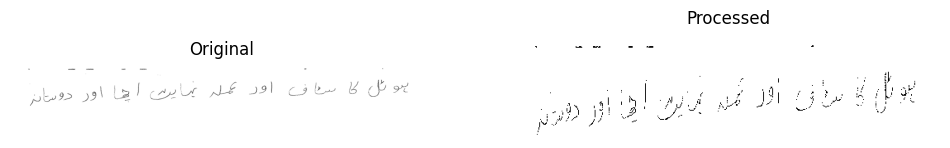

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import glob

original = glob.glob("/content/data/raw/Urdu OCR/**/*.png", recursive=True)[0]

processed = "/content/data/processed/" + os.path.basename(original)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(Image.open(original))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(Image.open(processed), cmap="gray")
plt.title("Processed")
plt.axis("off")

plt.show()

# Install Tesseract

In [ ]:
!apt-get install -y tesseract-ocr tesseract-ocr-urd
!pip install pytesseract

import pytesseract
from PIL import Image

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  tesseract-ocr-urd
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 1,000 kB of archives.
After this operation, 1,413 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-urd all 1:4.00~git30-7274cfa-1.1 [1,000 kB]
Fetched 1,000 kB in 0s (6,417 kB/s)
Selecting previously unselected package tesseract-ocr-urd.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-urd_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-urd (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-urd (1:4.00~git30-7274cfa-1.1) ...


# Test OCR

In [ ]:
import glob

test_images = glob.glob("/content/data/raw/Urdu OCR/Urdu lines/*.png")[:5]

print("Tesseract OCR Results\n")

for img_path in test_images:

    img = Image.open(img_path)

    text = pytesseract.image_to_string(
        img,
        lang="urd"
    )

    print("Image:", os.path.basename(img_path))
    print("OCR Output:")
    print(text)
    print("-"*50)

Tesseract OCR Results

Image: textbox_3_line_1_.png
OCR Output:
نا یے

--------------------------------------------------
Image: textbox_18_line_1_.png
OCR Output:

--------------------------------------------------
Image: textbox_9_line_2_.png
OCR Output:

--------------------------------------------------
Image: textbox_25_line_2_.png
OCR Output:

--------------------------------------------------
Image: textbox_29_line_2_.png
OCR Output:
کہ و ہر گجرس حس

گطھم جودج

لے
را

سض _

--------------------------------------------------


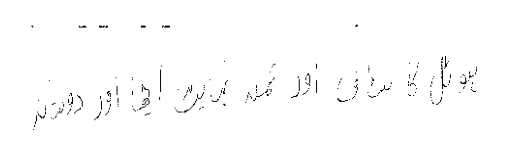

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open("/content/data/processed/textbox_3_line_1_.png")

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

# Gap Analysis

Image 1 – textbox_3_line_1_.png

Actual Text:
نا ہے

Issue:
Only a small part of the sentence was recognized. Most of the words were missing

Image 2 – textbox_18_line_1_.png

Actual Text:
No output

Issue:
Tesseract failed to detect any Urdu text
(same for image 3 & 4)

Image 5 – textbox_29_line_2_.png

Actual Text:
کمر و بر گھیری ہیں
گگھم جوج
لے
را
سن_

Issue:
Some Urdu words were detected, but the output is incomplete and contains recognition errors

# Summary

Tesseract fails on Urdu because Urdu is a cursive script where characters change shape depending on their position in a word
Similar-looking characters, ligatures & variations in fonts make recognition difficult
During testing, Tesseract either recognized only a few words, produced incomplete text or failed to detect any text

These limitations show that a dedicated Urdu OCR model is needed for accurate text recognition